# Traffic Accident Analysis
Analyzing Road Traffic Accidents in Ethiopia

**Authors:** Brian Muuo & Sharon Mungai

**Course:** DSA1080

---

**Project Overview** 
- Road traffic accidents(RTAs) are a major public health and safety concern in Ethiopia.

- This project analyzes a real-world traffic accident dataset to identify patterns related to drivers, vehicles, road conditions, weather conditions, and accident severity. Through data cleaning, exploratory data analysis (EDA), and visualization, the project aims to generate insights that can support road safety planning and policy decisions.

**Problem Statement**
- Although traffic accident data is routinely collected, it is often underutilized for decision-making. Many important factors such as driver experience, weather conditions, road conditions, and vehicle characteristics may influence accident severity but are not always analyzed systematically.

- This project seeks to identify the major contributors to traffic accidents and determine the characteristics associated with severe accidents.

**Objectives**
The objectives of this project are to:
 
- Clean and prepare the traffic accident dataset.
- Handle missing values values and inconsistent records.
- Explore accident patterns using descriptive statistics.
- Visualize important trends.
- Identify factors associated with accident severity.
- Provide recommendations based on findings.

**Target Users**
- Road safety authorities, traffic police, urban planners, and insurance companies.

---


## 1. Importing Required Libraries

In [1]:
# Create text file with necessary packages needed for the project
packages= ["pandas>=2.2.0",
           "numpy>=2.0.0",
           "matplotlib>=3.9.0",
           "seaborn>=0.13.2",
           "jupyter>=1.1.0",
           "notebook>=7.0.0"]

with open("../requirements.txt", "w") as file: #..\requirements- creates the txt file one folder up from where the current notebook is in
    file.write("\n".join(packages))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
# Display settings so wide dataframes are easier to read in the notebook

The project uses Pandas for data manipulation, NumPy for numerical operations, and visualization libraries such as Matplotlib and Seaborn.

## 2. Load the Dataset

In [3]:
# change the path of the dataset to your local path where the dataset is stored
df = pd.read_csv("C:\\Users\\user\\Downloads\\USIU_US26\\Traffic_Accident_Analysis\\data\\RTA Dataset.csv") 


The traffic accident dataset is loaded into a Pandas DataFrame for analysis.

An initial inspection is then performed to understand the structure of the dataset before any cleaning operations.

## 3. Preview the Data

In [4]:
# First 5 rows
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [5]:
# Last 5 rows
df.tail()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,No defect,Outside rural areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Escarpments,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,1,1,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,No defect,Office areas,Undivided Two way,Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury
12315,13:55:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Other,Owner,2-5yrs,No defect,Outside rural areas,Undivided Two way,Tangent road with mountainous terrain and,O Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Stopping,Pedestrian,Female,5,3,Driver,Normal,Crossing from nearside - masked by parked or s...,Changing lane to the right,Slight Injury


- The first and last five rows provide an initial overview of the dataset.

- From these records, we can observe that ```each row represents a single reported road traffic accident```, while ```each column describes a specific characteristic of that accident```, such as the driver, vehicle, road environment, weather conditions, and accident severity.

- Previewing the data also helps us identify obvious formatting issues, unexpected values, or missing information before beginning the cleaning process.

### Data Shape

In [6]:
#dataset shape
rows, cols = df.shape
print("Number of rows:", rows)
print("Number of columns:",cols)

Number of rows: 12316
Number of columns: 32


- The dataset contains **12,316 accident records** and **32 variables**.

- A relatively large number of observations provides enough information to identify meaningful trends and patterns during the analysis. 
The 32 variables capture different aspects of road traffic accidents, including driver characteristics, vehicle information, road conditions, casualty information, and accident outcomes.

### Data Types

In [7]:
#data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

- The dataset contains both numerical and categorical variables.

- Most of the variables are currently stored as **object** data types because they contain text.
- However, not all object variables truly represent text. Some represent categories (such as weather conditions or accident severity), while others represent time.

- Later in the cleaning process, these variables will be converted into more appropriate data types to improve memory usage and make analysis and visualization easier.

### Column Names

In [8]:
columns = df.columns
for index, col in enumerate(columns, start=1): # enumerate is generating a sequence of column names paired up with their index numbers.
    print(f"{index}.{col}")
    # print(str(index) + "." + col)

1.Time
2.Day_of_week
3.Age_band_of_driver
4.Sex_of_driver
5.Educational_level
6.Vehicle_driver_relation
7.Driving_experience
8.Type_of_vehicle
9.Owner_of_vehicle
10.Service_year_of_vehicle
11.Defect_of_vehicle
12.Area_accident_occured
13.Lanes_or_Medians
14.Road_allignment
15.Types_of_Junction
16.Road_surface_type
17.Road_surface_conditions
18.Light_conditions
19.Weather_conditions
20.Type_of_collision
21.Number_of_vehicles_involved
22.Number_of_casualties
23.Vehicle_movement
24.Casualty_class
25.Sex_of_casualty
26.Age_band_of_casualty
27.Casualty_severity
28.Work_of_casuality
29.Fitness_of_casuality
30.Pedestrian_movement
31.Cause_of_accident
32.Accident_severity


The dataset consists of 32 variables describing different aspects of traffic accidents. 

These variables can be grouped into five major categories:

1. **Driver Characteristics:** Age, sex, education, driving experience, and relationship to the vehicle.

2. **Vehicle Characteristics:** Vehicle type, ownership, service years, and mechanical defects.

3. **Road and Environmental Conditions:** Road type, road condition, weather, lighting, junction type, and accident location.

4. **Casualty Information:** Casualty class, age, gender, severity, occupation, and physical fitness.

5. **Accident Information:** Collision type, vehicle movement, number of vehicles involved, number of casualties, cause of accident, and accident severity.

The primary outcome of interest in this project is **Accident Severity**, while the other variables are used as explanatory factors to understand patterns associated with traffic accidents.

### Statistical Description of the Dataset

In [9]:
# summary of all columns(for both categorical and numerical columns)
df.describe(include= "all")

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11575,11737,11487,11366,11834,8388,7889,12077,11931,12174,11429,12144,12316,12316,12316,12161,12316.000000,12316.000000,12008,12316,12316,12316,12316,9118,9681,12316,12316,12316
unique,1074,7,5,3,7,4,7,17,4,6,3,14,7,9,8,5,4,4,9,10,NaN,NaN,13,4,3,6,4,7,5,9,20,3
top,15:30:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,No defect,Other,Two-way (divided with broken lines road marking),Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,NaN,NaN,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,120,2041,4271,11437,7619,9627,3363,3205,10459,2883,7777,3819,4411,10459,4543,11296,9340,8798,10063,8774,NaN,NaN,8158,4944,5253,4443,7076,5903,9608,11390,2263,10415
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.040679,1.548149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.688790,1.007179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- The descriptive statistics provide a summary of the numerical and object variables in the dataset.

- They show the minimum, maximum, average and spread of numerical values such as the number of vehicles involved and the number of casualties.
- They also show the most frequent vlaues of the object variables.

- At this stage, the statistics are mainly used to understand the data and identify values that may require further investigation during cleaning.

## 3. Check for Missing values, duplicates and Unique values

### Check Missing values

In [10]:
missing_vals= df.isna().sum()
missing_percent= ((missing_vals / len(df)) * 100).round(2)

missing_summary= pd.DataFrame({
    "Missing_Count":missing_vals,
    "Missing_Percentage":missing_percent
}).sort_values(by="Missing_Count", ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Defect_of_vehicle,4427,35.95
Service_year_of_vehicle,3928,31.89
Work_of_casuality,3198,25.97
Fitness_of_casuality,2635,21.39
Type_of_vehicle,950,7.71
Types_of_Junction,887,7.20
Driving_experience,829,6.73
Educational_level,741,6.02
Vehicle_driver_relation,579,4.70
Owner_of_vehicle,482,3.91


- The missing value summary shows that not every variable was recorded for every accident.

- Some variables contain very few missing values, while others have a huge amount of missing information. This is common in real-world datasets where some information may not have been available or recorded at the time of the accident.

- Before deciding how to handle the missing values, it is important to understand **how much information is missing** and **whether the missing values are likely to affect the analysis**.

### Check for Duplicates

- Duplicate records here refer to identical accident reports appearing more than once in the dataset.

In [11]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# To check if there are any duplicate columns
print(df.columns.duplicated().any())

Number of duplicate rows: 0
False


- The output shows that there are no duplicate observations.

- Therefore, no records needed to be removed, and every row represents a unique accident report.

### Check for uniques values

- Checking for unique values helps in identfying inconsistencies in entries, errors or improper formatting, especially within categorical variables.

In [12]:
for col in columns:
    if df[col].dtype == "object":
        print(f"Unique values in {col}:",df[col].unique())
        print("\n")

Unique values in Time: ['17:02:00' '1:06:00' '14:15:00' ... '7:24:00' '19:18:00' '2:47:00']


Unique values in Day_of_week: ['Monday' 'Sunday' 'Friday' 'Wednesday' 'Saturday' 'Thursday' 'Tuesday']


Unique values in Age_band_of_driver: ['18-30' '31-50' 'Under 18' 'Over 51' 'Unknown']


Unique values in Sex_of_driver: ['Male' 'Female' 'Unknown']


Unique values in Educational_level: ['Above high school' 'Junior high school' nan 'Elementary school'
 'High school' 'Unknown' 'Illiterate' 'Writing & reading']


Unique values in Vehicle_driver_relation: ['Employee' 'Unknown' 'Owner' nan 'Other']


Unique values in Driving_experience: ['1-2yr' 'Above 10yr' '5-10yr' '2-5yr' nan 'No Licence' 'Below 1yr'
 'unknown']


Unique values in Type_of_vehicle: ['Automobile' 'Public (> 45 seats)' 'Lorry (41?100Q)' nan
 'Public (13?45 seats)' 'Lorry (11?40Q)' 'Long lorry' 'Public (12 seats)'
 'Taxi' 'Pick up upto 10Q' 'Stationwagen' 'Ridden horse' 'Other' 'Bajaj'
 'Turbo' 'Motorcycle' 'Special vehicle' 'Bi

During this step, several issues were identified, including:

- inconsistent spelling,
- unnecessary spaces,
- different ways of writing the same category,
- placeholder values such as "Unknown",
- and data entry errors.

Identifying these inconsistencies early ensures that categories representing the same meaning are not treated as separate groups during analysis.

## 4. Feature Selection
Not every variable in the original dataset contributes directly to the objectives of this project.

Columns with limited analytical value or excessive missing information were excluded to reduce noise and simplify the analysis.

The retained variables focus on:

- Driver characteristics
- Vehicle information
- Road environment
- Weather conditions
- Casualty information
- Accident severity

In [13]:
# columns we'll be working with for this project
core_columns = ["Time",
    "Day_of_week",
    "Age_band_of_driver",
    "Sex_of_driver",
    "Driving_experience",
    "Type_of_vehicle",
    "Area_accident_occured",
    "Road_surface_type",
    "Road_surface_conditions",
    "Weather_conditions",
    "Light_conditions",
    "Type_of_collision",
    "Number_of_vehicles_involved",
    "Number_of_casualties",
    "Vehicle_movement",
    "Sex_of_casualty",
    "Age_band_of_casualty",
    "Casualty_severity",
    "Cause_of_accident",
    "Accident_severity"]

# columns we can use for future analysis
optional_columns = ["Owner_of_vehicle",
    "Service_year_of_vehicle",
    "Fitness_of_casuality",
    "Pedestrian_movement"]

df2 = df[core_columns + optional_columns].copy()

In [14]:
rows, cols = df2.shape
print("Number of rows:", rows)
print("Number of columns:",cols)

Number of rows: 12316
Number of columns: 24


A new dataset (`df2`) containing only the most relevant variables was created. This reduces unnecessary complexity while keeping the information needed for meaningful analysis.

## 5. Stanadardize Text Values

- Real-world datasets often contain inconsistent text formatting.

- For example, the same category may appear with leading spaces, extra spaces between words, or different spellings.

- Standardising the text ensures that values representing the same category are grouped together during analysis instead of being counted separately.

### Removing Whitespaces

In [15]:
# Remove (leading and trailing)whitespace from all object columns
object_cols = df2.select_dtypes(include="object").columns

df2[object_cols] = df2[object_cols].apply(lambda col: col.str.strip())

### Fix spelling or formatting errors

In [16]:
# Area Accident occured
df2["Area_accident_occured"] = (df2["Area_accident_occured"].str.strip())

# fix the merged entries
df2["Area_accident_occured"] = df2["Area_accident_occured"].replace({
    "Rural village areasOffice areas":"Rural village areas"
})

In [17]:
# Weather conditions
df2["Weather_conditions"] = df2["Weather_conditions"].replace({
    "Raining":"Rain",
    "Raining and Windy":"Rain & Wind"
})

In [18]:
# Cause of accident
df2["Cause_of_accident"] = df2["Cause_of_accident"].replace({
    "Driving at high speed": "Overspeed",
    "Turnorver":"Overturning"
})



In [19]:
# Casualty Age
def age_to_band(age):
    if pd.isna(age):
        return np.nan

    try:
        age = int(age)

        if age < 18:
            return "Under 18"
        elif age <= 30:
            return "18-30"
        elif age <= 50:
            return "31-50"
        else:
            return "Over 51"

    except ValueError:
        return age
    

df2["Age_band_of_casualty"] = (df2["Age_band_of_casualty"].apply(age_to_band))

In [20]:
# Fitness of casualty
df2["Fitness_of_casuality"] = df2["Fitness_of_casuality"].replace({
    "NormalNormal":"Normal"
})

In [21]:
# Casualty Severity Labels mapping
severity_map={"1":"Fatal Injury",
          "2":"Serious Injury",
          "3":"Slight Injury",
          "na": "Unknown"}

df2["Casualty_severity_label"]=(df2["Casualty_severity"].astype(str).map(severity_map))

In [22]:
# Fix errors in Type of vehicle column
df2["Type_of_vehicle"] = (df2["Type_of_vehicle"].str.replace("?", "-", regex=False))

### Verify

In [23]:
for col in df2.select_dtypes(include="object").columns:
    print(f"\n{col}({df2[col].nunique(dropna=True)}unique values)")
    print(sorted(df2[col].dropna().unique())) # sorted()-sorts values alphabetically


Time(1074unique values)
['0:01:00', '0:02:00', '0:03:00', '0:04:00', '0:06:00', '0:08:00', '0:09:00', '0:10:00', '0:11:00', '0:15:00', '0:17:00', '0:18:00', '0:19:00', '0:20:00', '0:21:00', '0:23:00', '0:25:00', '0:26:00', '0:28:00', '0:29:00', '0:30:00', '0:31:00', '0:34:00', '0:35:00', '0:36:00', '0:40:00', '0:41:00', '0:43:00', '0:44:00', '0:45:00', '0:47:00', '0:50:00', '0:51:00', '0:52:00', '0:53:00', '0:54:00', '0:55:00', '0:56:00', '0:57:00', '10:00:00', '10:01:00', '10:02:00', '10:04:00', '10:05:00', '10:07:00', '10:08:00', '10:10:00', '10:11:00', '10:12:00', '10:13:00', '10:15:00', '10:16:00', '10:17:00', '10:18:00', '10:19:00', '10:20:00', '10:21:00', '10:22:00', '10:23:00', '10:24:00', '10:25:00', '10:26:00', '10:27:00', '10:29:00', '10:30:00', '10:31:00', '10:32:00', '10:34:00', '10:35:00', '10:36:00', '10:37:00', '10:38:00', '10:39:00', '10:40:00', '10:41:00', '10:42:00', '10:43:00', '10:44:00', '10:45:00', '10:47:00', '10:48:00', '10:49:00', '10:50:00', '10:51:00', '10:5

- After standardisation, the unique values were checked again to confirm that inconsistent spellings, unnecessary spaces and formatting issues had been successfully corrected.

- This step ensures that the dataset is clean before proceeding to data type conversion and missing value handling.

## 6.  Convert to Right data types

Variables are converted into appropriate data types to improve both the efficiency and accuracy of the analysis. 

For example: 
- Time values can now be grouped by hour.
- Numerical variables can be used in mathematical calculations.
- Categorical variables are easier to summarize and visualize.


**The following conversions are performed:**

- Time  to datetime/time
- Categorical variables to category
- Numerical variables to integer

### Convert To Time Type

In [24]:
df2["Time"]= (pd.to_datetime(df2["Time"],
                             format= "%H:%M:%S",
                             errors="coerce")
                             .dt.time)

In [25]:
df2["Time"].head()

0    17:02:00
1    17:02:00
2    17:02:00
3    01:06:00
4    01:06:00
Name: Time, dtype: object

### Convert To numeric Type

In [26]:
# INTEGER
numeric_columns = ["Number_of_vehicles_involved", "Number_of_casualties"]

for col in numeric_columns:
    df2[col] = (pd.to_numeric(df2[col],
            errors="coerce").astype("Int64"))
    print(df2[col].head())

0    2
1    2
2    2
3    2
4    2
Name: Number_of_vehicles_involved, dtype: Int64
0    2
1    2
2    2
3    2
4    2
Name: Number_of_casualties, dtype: Int64


### Convert To categorical Type

In [27]:
for col in df2.select_dtypes(include="object").columns:
    if col != "Time" :
        df2[col] = df2[col].astype("category")
print(df2.dtypes)

Time                             object
Day_of_week                    category
Age_band_of_driver             category
Sex_of_driver                  category
Driving_experience             category
Type_of_vehicle                category
Area_accident_occured          category
Road_surface_type              category
Road_surface_conditions        category
Weather_conditions             category
Light_conditions               category
Type_of_collision              category
Number_of_vehicles_involved       Int64
Number_of_casualties              Int64
Vehicle_movement               category
Sex_of_casualty                category
Age_band_of_casualty           category
Casualty_severity              category
Cause_of_accident              category
Accident_severity              category
Owner_of_vehicle               category
Service_year_of_vehicle        category
Fitness_of_casuality           category
Pedestrian_movement            category
Casualty_severity_label        category


The updated data types confirm that each variable is now stored in a format appropriate for analysis and visualization.

## 7. Ordering Ordinal variables

In [28]:
from pandas.api.types import CategoricalDtype

# Day of Week
day_order= CategoricalDtype(categories=["Sunday",
                                        "Monday",
                                        "Tuesday",
                                        "Wednesday",
                                        "Thursday",
                                        "Friday"],
                                        ordered=True)
df2["Day_of_week"]=(df2['Day_of_week'].astype(day_order))


# Age bands
age_order= CategoricalDtype(categories=["Under 18",
                                        "18-30",
                                        "31-50",
                                        "Over 51"], ordered=True)

df2["Age_band_of_casualty"]=(df2["Age_band_of_casualty"].astype(age_order))
df2["Age_band_of_driver"]=(df2["Age_band_of_driver"].astype(age_order))


# Driving Experience
experience_order= CategoricalDtype(categories=["No License",
                                               "Below 1yr",
                                               "1-2yr",
                                               "2-5yr",
                                               "5-10yr",
                                               "Above 10yr"],
                                               ordered=True)

df2["Driving_experience"]=(df2["Driving_experience"].astype(experience_order))


# Service year of vehicle
service_yr_order= CategoricalDtype(categories=["Below 1yr",
                                               "1-2yr",
                                               "2-5yrs",
                                               "5-10yrs",
                                               "Above 10yr"],
                                               ordered=True)

df2["Service_year_of_vehicle"]=(df2["Service_year_of_vehicle"].astype(service_yr_order))


# Accident Severity
severity_order= CategoricalDtype(categories=["Slight Injury", 
                                 "Serious Injury",
                                 "Fatal Injury"],
                                 ordered=True)

df2["Accident_severity"]=(df2["Accident_severity"].astype(severity_order))

In [29]:
df2.dtypes

Time                             object
Day_of_week                    category
Age_band_of_driver             category
Sex_of_driver                  category
Driving_experience             category
Type_of_vehicle                category
Area_accident_occured          category
Road_surface_type              category
Road_surface_conditions        category
Weather_conditions             category
Light_conditions               category
Type_of_collision              category
Number_of_vehicles_involved       Int64
Number_of_casualties              Int64
Vehicle_movement               category
Sex_of_casualty                category
Age_band_of_casualty           category
Casualty_severity              category
Cause_of_accident              category
Accident_severity              category
Owner_of_vehicle               category
Service_year_of_vehicle        category
Fitness_of_casuality           category
Pedestrian_movement            category
Casualty_severity_label        category


## 8. Handling Missing values

#### Why are Missing Values Important?

- Missing values are common in real-world datasets because some information **may not have been recorded**, **may have been unavailable**, or **may not apply to a particular accident**.

- Before deciding how to handle missing values, the number and percentage of missing values in each column were calculated.

- The aim was to preserve as many accident records as possible while avoiding unrealistic assumptions about missing information.

In [30]:
missing_vals= df2.isna().sum()
missing_percent= ((missing_vals / len(df2)) * 100).round(2)

missing_summary= pd.DataFrame({
    "Missing_Count":missing_vals,
    "Missing_Percentage":missing_percent
}).sort_values(by="Missing_Count", ascending=False)

print(missing_summary)
df2.shape

                             Missing_Count  Missing_Percentage
Service_year_of_vehicle               6811               55.30
Age_band_of_casualty                  4443               36.08
Fitness_of_casuality                  2635               21.39
Day_of_week                           1666               13.53
Age_band_of_driver                    1548               12.57
Driving_experience                     980                7.96
Type_of_vehicle                        950                7.71
Owner_of_vehicle                       482                3.91
Vehicle_movement                       308                2.50
Area_accident_occured                  239                1.94
Road_surface_type                      172                1.40
Accident_severity                      158                1.28
Type_of_collision                      155                1.26
Pedestrian_movement                      0                0.00
Casualty_severity                        0             

(12316, 25)

- The table shows that some variables contained no missing values, while others had varying amounts of missing data.

- A few variables, such as **Service_year_of_vehicle**, **Age_band_of_casualty**, and **Fitness_of_casuality**, contained relatively high percentages of missing observations, while many other variables had only a small percentage of missing observations.

- Different imputation strategies were therefore applied depending on:
    1. The percentage of missing values,
    2. The importance of the variable,
    3. The meaning of the missing information.

- This approach helps preserve as much useful information as possible while improving the quality of the dataset.

### Missing values less than / equal to 15%

#### Fill in with mode values

#### Why was the mode used?

- Variables with relatively small amounts of missing data (15% or less) were filled using the **most frequently occurring value (mode)**.

- The mode was selected because these variables are categorical, making it the most appropriate measure of central tendency.

- Using the mode helps maintain the size of the dataset while introducing only a small amount of bias, since relatively few observations were missing.

In [31]:
# select cols with >0% and <=15% missing values
mode_cols=missing_summary[(missing_summary["Missing_Percentage"]> 0) & (missing_summary["Missing_Percentage"]<= 15)].index

for col in mode_cols:
    df2[col]= df2[col].fillna(df2[col].mode()[0])

After mode imputation, all selected variables contained no missing values.

Because the percentage of missing observations was relatively low, replacing them with the most common category was unlikely to substantially affect the overall distribution of the data.

### Missing values greater than 15%

#### Fill null values with placeholder "Unknown"

In [32]:
# Handle casualty-related variables with substantial missing values

casualty_cols = [
    "Age_band_of_casualty",
    "Fitness_of_casuality"]

for col in casualty_cols:

    # Add "Unknown" only if it doesn't already exist
    if "Unknown" not in df2[col].cat.categories:
        df2[col] = df2[col].cat.add_categories("Unknown")

    # Replace missing values
    df2[col] = df2[col].fillna("Unknown")


In [33]:
# Replace missing service years with the existing "Unknown" category

if "Unknown" not in df2["Service_year_of_vehicle"].cat.categories:
    df2["Service_year_of_vehicle"] = (df2["Service_year_of_vehicle"]
        .cat.add_categories("Unknown"))

df2["Service_year_of_vehicle"] = (df2["Service_year_of_vehicle"]
    .fillna("Unknown"))

- Variables with more than 15% missing values required a different treatment from those with relatively few missing observations.

- Using the mode for these variables would have assigned thousands of records to the most common category, which could distort the true distribution of the data. At the same time, removing these records would have resulted in the loss of a large amount of valuable accident information.

- Two approaches were therefore used:

    1. **Age_band_of_casualty** and **Fitness_of_casuality** had missing values replaced with the category **"Unknown"**. This preserves all accident records while clearly indicating that the original information was unavailable.

    2. **Service_year_of_vehicle** already contained an **"Unknown"** category. Therefore, all missing values were assigned to this existing category to maintain consistency.

    This approach retains all observations in the dataset while avoiding unsupported assumptions about missing information.

In [34]:
high_missing_cols = [
    "Age_band_of_casualty",
    "Fitness_of_casuality",
    "Service_year_of_vehicle"
]

print(df2[high_missing_cols].isna().sum())

Age_band_of_casualty       0
Fitness_of_casuality       0
Service_year_of_vehicle    0
dtype: int64


- After applying the two methods above, all variables contained complete information with no remaining missing values.

- Replacing missing observations with **"Unknown"** ensures that these records remain available for analysis and can be interpreted separately from known categories. This preserves the size of the dataset and allows optional variables, such as **Service_year_of_vehicle**, to be explored in future analyses if required.

In [35]:
df2.isnull().sum()

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Driving_experience             0
Type_of_vehicle                0
Area_accident_occured          0
Road_surface_type              0
Road_surface_conditions        0
Weather_conditions             0
Light_conditions               0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Cause_of_accident              0
Accident_severity              0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Fitness_of_casuality           0
Pedestrian_movement            0
Casualty_severity_label        0
dtype: int64

- After applying the appropriate missing value strategies to each variable, the cleaned dataset contains no remaining missing values in the selected variables.

- The dataset is now cleaner and more reliable for exploratory data analysis.

## 9. Export the Dataset

In [36]:
try:
    df2.to_csv("C:/Users/user/Downloads/USIU_US26/Traffic_Accident_Analysis/data/cleaned_rta_data.csv", index=False)
except NameError:
    df2 = df[core_columns + optional_columns].copy()
    df2.to_csv("C:/Users/user/Downloads//USIU_US26/Traffic_Accident_Analysis/data/cleaned_rta_data.csv", index=False)

- The cleaned dataset is saved as a CSV file and is now ready for exploratory data analysis (EDA).
- Saving the cleaned data ensures that future analyses can begin directly from the prepared dataset without repeating the entire cleaning process.

- It also creates a permanent record of the preprocessing steps completed during this stage of the project.

- **Cleaning activities completed include:**

1. ```Feature selection```: selected the variables relevant to the project objectives.
2. ```Text standardization```: Standardized text values by removing unnecessary spaces and correcting inconsistent labels.
3. ```Missing value handling```: handled missing values using different methods based on the percentage and meaning of the missing data.
4. ```Data type conversion```: converted variables into appropriate data types.
5. ```Removal of inconsistencies```: corrected data entry errors.

- The cleaned dataset is exported for exploratory data analysis.

## 10. Exploratory Data Analysis

After cleaning and preparing the dataset, the next step is to explore it using **Exploratory Data Analysis (EDA)**.

EDA helps summarize the main characteristics of the data through descriptive statistics and visualizations. Rather than testing hypotheses, it allows us to identify patterns, trends, unusual observations and potential relationships that may explain road traffic accidents.

For clarity, the analysis has been organised into three categories:

- **Univariate Analysis** – examines one variable at a time.
- **Bivariate Analysis** – examines the relationship between two variables.
- **Multivariate Analysis** – examines relationships involving more than two variables.

The findings from this section will be used to answer the project's analysis questions: 

    1. How many traffic accidents were recorded?
    2. Which locations experience the most accidents?
    3. What time of the day do most accidents occur?
    4. Which days of the week have the highest accident frequency?
    5. What are the leading causes of accidents?
    6. Which weather conditions are associated with accidents?
    7. What is the distribution of accident severity?
    8. Which vehicle types are most involved in accidents?
    9. Which road users are most affected?

This section begins with univariate analysis to understand the individual characteristics of the dataset before exploring more complex relationships.

Q1: HOW MANY ACCIDENTS WERE RECORDED ?

In [37]:
# Summary statistic: total row count = total recorded accidents
total_accidents = len(df2)
print(f"Total traffic accidents recorded: {total_accidents}")

Total traffic accidents recorded: 12316


- The dataset contains **12,316 recorded traffic accidents**.

- Each row represents one reported accident. Having a large number of observations increases the reliability of the analysis because it reduces the influence of unusual or isolated events.

Q2: WHICH LOCATIONS EXPERIENCED THE MOST ACCIDENTS ?

Understanding where accidents occur most frequently helps identify accident-prone areas that may require road safety improvements, better traffic management or increased enforcement.

To answer this question, the number of accidents reported in each accident location was calculated and visualized using a horizontal bar chart.

In [48]:
# value_counts + sorting: rank accident locations
location_counts = (df2["Area_accident_occured"]
                    .value_counts()
                    .sort_values(ascending=False))

location_counts = location_counts[location_counts > 0]
location_table = location_counts.rename("Accident_Count").to_frame()
location_table

,Accident_Count
Area_accident_occured,
Other,4058
Office areas,3451
Residential areas,2060
Church areas,1060
Industrial areas,456
School areas,415
Recreational areas,328
Outside rural areas,218
Hospital areas,121


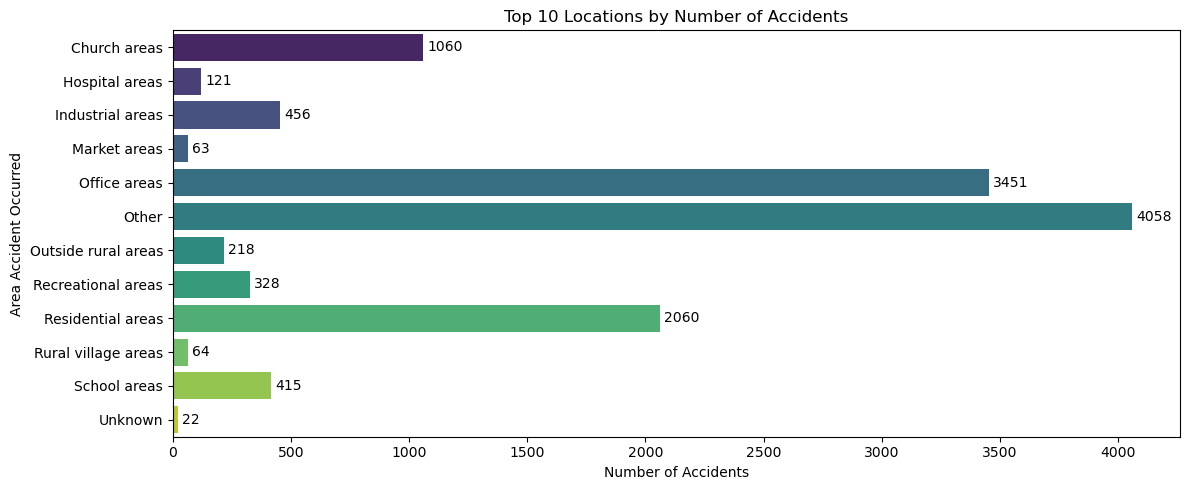

In [ ]:
# Visual: top 10 accident locations
plt.figure(figsize=(12,5))

ax= sns.barplot(x=location_table["Accident_Count"],
             y=location_table.index,
            hue=location_table.index,
            palette="viridis",
            legend= False)

for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title("Locations by Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Area Accident Occurred")
plt.tight_layout()
plt.show()

- The results show that the **"Other"** category recorded the highest number of accidents, with **4,058 cases**. However, since this category combines several unspecified or less common locations, it provides limited practical information for identifying specific accident hotspots.

- Among the clearly defined locations, **Office areas** recorded the highest number of accidents (**3,451 cases**), followed by **Residential areas** (**2,060 cases**) and **Church areas** (**1,060 cases**). These three locations account for a substantial proportion of the reported accidents in the dataset.

- The high number of accidents in office areas may be associated with increased traffic during commuting hours, frequent vehicle movements and pedestrian activity. 
- Similarly, residential areas experience continuous interaction between vehicles, pedestrians and cyclists, increasing the likelihood of road accidents.

- In contrast, **Hospital areas (121 accidents)** and **Rural village areas (64 accidents)** recorded the lowest accident frequencies. This may be attributed to lower traffic volumes, reduced vehicle speeds or fewer reported accidents in these locations.

Q3 : WHAT TIME OF DAY DO MOST ACCIDENTS OCCUR ?

- The time at which accidents occur can provide useful information about traffic patterns and periods of increased road risk.

- To answer this question, the accident time was converted into hours (24-hour format), after which the total number of accidents occurring in each hour of the day was calculated and displayed using a line chart.

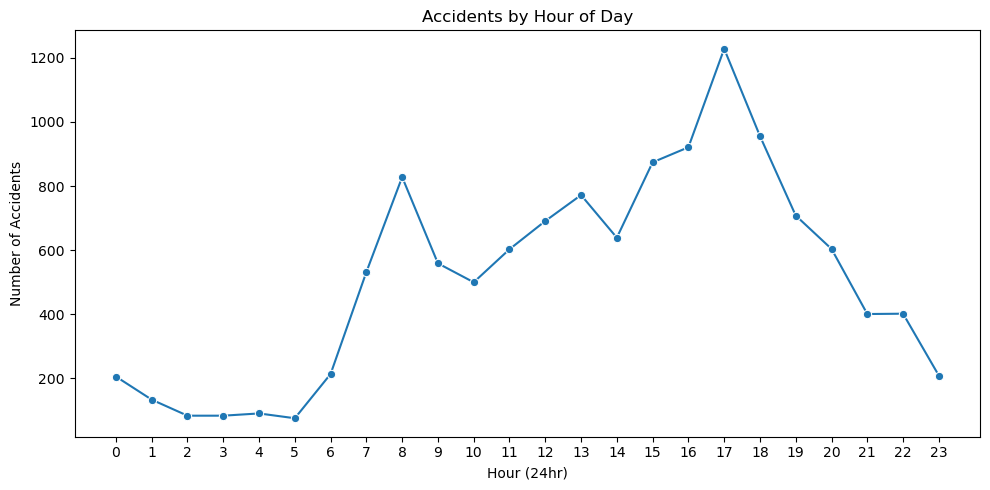

In [40]:
# Extract hour from Time, then group + aggregate (count) by hour
df2["Hour"] = df2["Time"].apply(lambda t: t.hour if pd.notna(t) else np.nan)

hourly_counts = (df2.groupby("Hour", observed=True)
                  .size()
                  .sort_values(ascending=False))

hourly_table = hourly_counts.rename("Accident_Count").to_frame()
hourly_table.head(10)


# Visual: accidents across all 24 hours, in time order (not sorted by count)
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_counts.sort_index().index, y=hourly_counts.sort_index().values, marker="o")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour (24hr)")
plt.ylabel("Number of Accidents")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

- The line chart shows that traffic accidents are not evenly distributed throughout the day. Accident frequencies are lowest during the early morning hours (between midnight and approximately 5:00 a.m.), when fewer vehicles are likely to be on the road.

- The number of accidents begins to increase from **6:00 a.m.**, with a noticeable morning peak occurring around **8:00 a.m.** This coincides with the period when many people are travelling to work or school.

- Accident frequencies remain relatively high throughout the afternoon before reaching the **highest peak at 5:00 p.m. (17:00 hours)**. This suggests that the evening rush hour experiences the greatest number of traffic accidents, possibly due to increased traffic congestion, driver fatigue after work, and a higher number of road users.

- After 6:00 p.m., the number of accidents gradually decreases as traffic volume reduces during the night.

Q4: WHICH DAYS OF THE WEEK HAVE THE HIGHEST ACCIDENT FREQUENCY ?

Road traffic patterns often vary throughout the week due to differences in work schedules, business activities and travel behaviour.

To determine whether accidents occur more frequently on certain days, the total number of accidents was calculated for each day of the week and displayed using a bar chart.

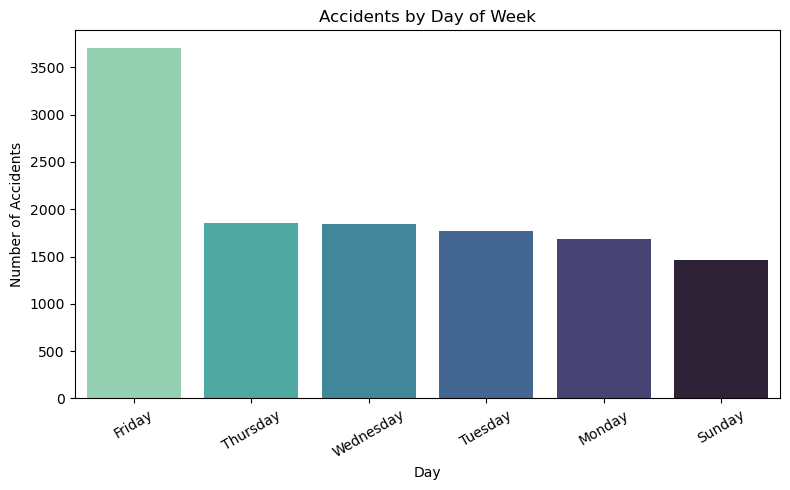

In [52]:
# value_counts on an ordered categorical column
day_counts = df2["Day_of_week"].value_counts().sort_values(ascending=False)
day_table = day_counts.rename("Accident_Count").to_frame()
day_table



plt.figure(figsize=(8,5))
sns.barplot(x=day_table.index, y=day_table["Accident_Count"], order=day_table.index, hue=day_table.index,  palette="mako", legend= False)
plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


- The results show that **Friday** recorded the highest number of traffic accidents, with approximately **3,700 reported cases**. This is considerably higher than any other day of the week.

- **Thursday** and **Wednesday** recorded the next highest accident frequencies, followed closely by **Tuesday** and **Monday**. In comparison, **Sunday** had the lowest number of reported accidents.

- The higher accident frequency on Fridays may be associated with increased traffic as people travel for work, business, shopping or social activities before the weekend. On the other hand, the lower number of accidents on Sundays may reflect reduced traffic volumes as fewer people commute to work or school.

Q5: WHAT ARE THE LEADING CAUSES OF ACCIDENTS ?

Understanding the major causes of traffic accidents helps identify risky driving behaviours that contribute most to road crashes.

To answer this question, the number of accidents associated with each reported cause was calculated and visualized using a horizontal bar chart.

In [57]:
cause_counts = (df2["Cause_of_accident"]
                 .value_counts()
                 .sort_values(ascending=False))
cause_table = cause_counts.rename("Accident_Count").to_frame()
cause_table

,Accident_Count
Cause_of_accident,
No distancing,2263
Changing lane to the right,1808
Changing lane to the left,1473
Driving carelessly,1402
No priority to vehicle,1207
Moving Backward,1137
No priority to pedestrian,721
Other,456
Overtaking,430


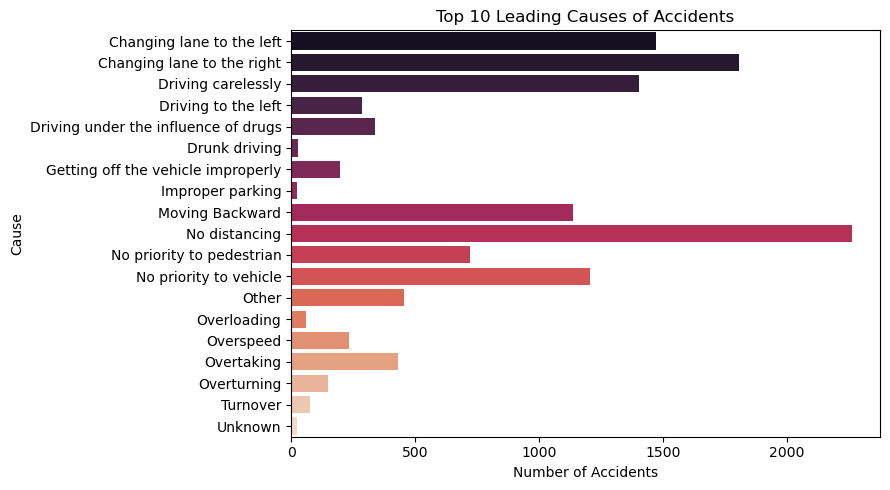

In [ ]:
plt.figure(figsize=(9,5))
ax= sns.barplot(x=cause_table["Accident_Count"], y=cause_table.index, hue=cause_table.index,
    palette="rocket",
    legend=False)
plt.title("Leading Causes of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Cause")
plt.tight_layout()
plt.show()

- The analysis shows that **No distancing** is the leading reported cause of traffic accidents, accounting for **2,263 cases**. This indicates that failing to maintain a safe following distance is the most common factor associated with accidents in the dataset.

- The next most frequent causes are **Changing lane to the right (1,808 cases)**, **Changing lane to the left (1,473 cases)**, and **Driving carelessly (1,402 cases)**. These results suggest that unsafe driving behaviours related to lane changing and careless driving contribute substantially to road traffic accidents.

- Other important causes include **No priority to vehicle (1,207 cases)** and **Moving Backward (1,137 cases)**, both of which were also reported in a large number of accidents.

- In contrast, causes such as **Drunk driving (27 cases)**, **Improper parking (25 cases)**, and **Unknown (25 cases)** were reported relatively infrequently in this dataset.

- Overall, the chart shows that a small number of driver-related behaviours account for a large share of the recorded accidents.

The results indicate that the majority of reported traffic accidents are associated with preventable driver behaviours. The most common causes are failure to keep a safe distance, improper lane changing, and careless driving. These findings suggest that improving driver discipline and adherence to traffic rules could potentially reduce a substantial proportion of road traffic accidents.

Q6: WHAT WEATHER CONDITIONS ARE ASSSOCIATED WITH ACCIDENTS ?

Weather conditions can influence road visibility, vehicle control and driving behaviour, all of which affect the likelihood and severity of road traffic accidents.

To answer this question, the number of accidents occurring under each weather condition was calculated. In addition, the accident severity within each weather condition was examined to determine whether certain weather conditions were associated with more severe accidents.

In [43]:
weather_counts = df2["Weather_conditions"].value_counts().sort_values(ascending=False)
weather_table = weather_counts.rename("Accident_Count").to_frame()
weather_table


# Grouping + aggregation: severity breakdown within each weather condition
weather_severity = (df2.groupby("Weather_conditions", observed=True)["Accident_severity"]
                     .value_counts()
                     .unstack(fill_value=0))
weather_severity

Accident_severity,Slight Injury,Serious Injury,Fatal Injury
Weather_conditions,,,
Cloudy,117,8,0
Fog or mist,9,1,0
Normal,8589,1474,0
Other,268,28,0
Rain,1173,158,0
Rain & Wind,38,2,0
Snow,56,5,0
Unknown,241,51,0
Windy,82,16,0


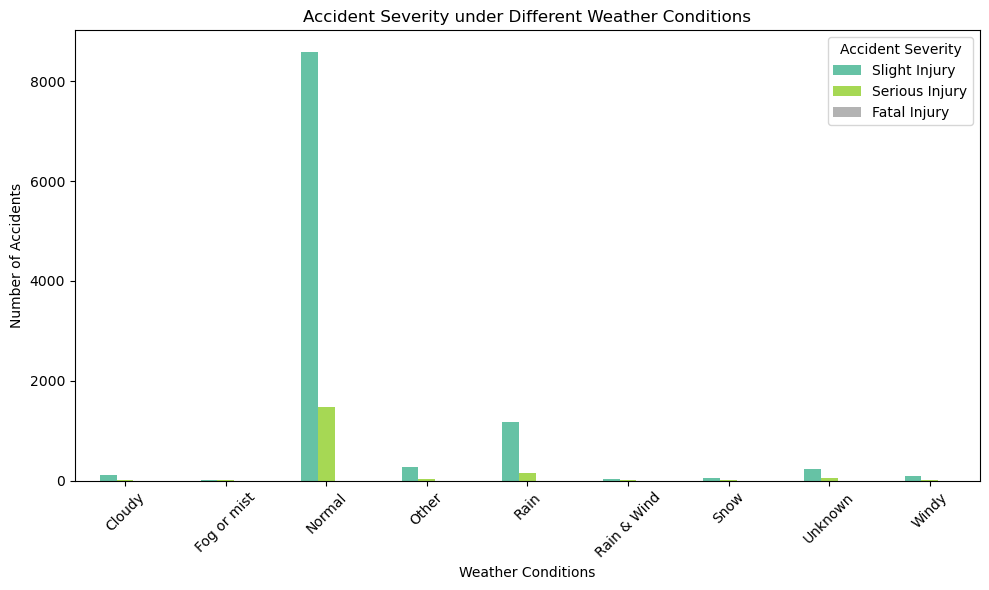

In [66]:
weather_severity.plot(
    kind="bar",
    figsize=(10,6),
    colormap="Set2"
)

plt.title("Accident Severity under Different Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.legend(title="Accident Severity")
plt.tight_layout()
plt.show()

- The results show that the majority of reported traffic accidents occurred under **Normal** weather conditions, with **8,589 slight injuries** and **1,474 serious injuries**. This is substantially higher than all other weather conditions.

- Rain was the second most common weather condition associated with accidents, recording **1,173 slight injuries** and **158 serious injuries**. Other conditions such as **Cloudy**, **Windy**, **Snow**, **Fog or mist**, and **Rain & Wind** contributed comparatively fewer accidents.

- No **fatal injuries** were recorded under any weather condition in this dataset. This suggests that while weather may influence accident occurrence, most recorded accidents resulted in either slight or serious injuries.

- The large number of accidents occurring during normal weather does not necessarily imply that good weather is more dangerous.
- Instead, it is likely that far more people travel during normal weather conditions than during adverse weather, leading to a higher overall number of reported accidents.

Q7: WHAT IS THE DISTRIBUTION OFACCIDENT SEVERITY ?

Understanding the distribution of accident severity helps determine whether most reported accidents result in minor, serious or fatal injuries.

To answer this question, the number and percentage of accidents in each severity category were calculated and presented using a pie chart.

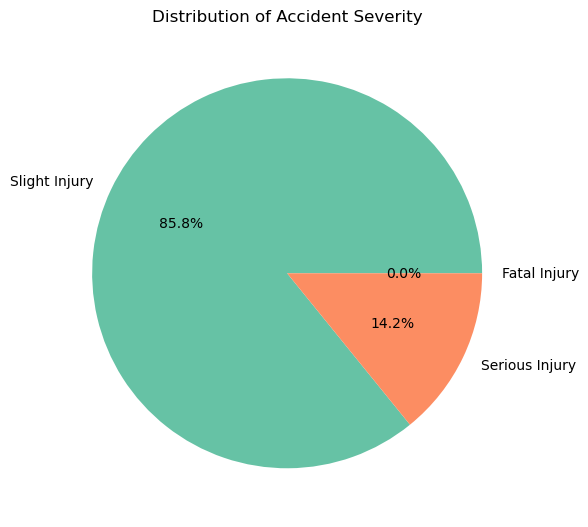

In [44]:
# value_counts with percentages (summary statistic)
severity_counts = df2["Accident_severity"].value_counts()
severity_percent = (severity_counts / severity_counts.sum() * 100).round(2)

severity_table = pd.DataFrame({
    "Count": severity_counts,
    "Percentage": severity_percent
})
severity_table


plt.figure(figsize=(6,6))
plt.pie(severity_table["Count"], labels=severity_table.index, autopct="%1.1f%%",
        colors=sns.color_palette("Set2"))
plt.title("Distribution of Accident Severity")
plt.tight_layout()
plt.show()

- The results show that **Slight Injury** accidents make up the overwhelming majority of reported cases, accounting for **85.8%** of all accidents in the dataset.

- **Serious Injury** accidents account for the remaining **14.2%**, indicating that although they occur less frequently, they still represent a significant proportion of road traffic accidents.

- No **Fatal Injury** cases were recorded in the cleaned dataset, as shown by the 0.0% share in the pie chart. This means that all analysed accidents resulted in either slight or serious injuries.

- Overall, the distribution indicates that most reported road traffic accidents in this dataset resulted in less severe injuries, with only a smaller proportion leading to serious injuries.

Q8: WHICH VEHICLE TYPES ARE MOST INVLOVED IN ACCIDENTS ?

Different types of vehicles have varying levels of road usage and operating conditions, which may influence their involvement in traffic accidents.

To answer this question, the number of accidents involving each vehicle type was calculated and the results were presented using a horizontal bar chart.

In [67]:
vehicle_counts = (df2["Type_of_vehicle"]
                   .value_counts()
                   .sort_values(ascending=False))
vehicle_table = vehicle_counts.rename("Accident_Count").to_frame()
vehicle_table

,Accident_Count
Type_of_vehicle,
Automobile,4155
Lorry (41-100Q),2186
Other,1208
Pick up upto 10Q,811
Public (12 seats),711
Stationwagen,687
Lorry (11-40Q),541
Public (13-45 seats),532
Public (> 45 seats),404


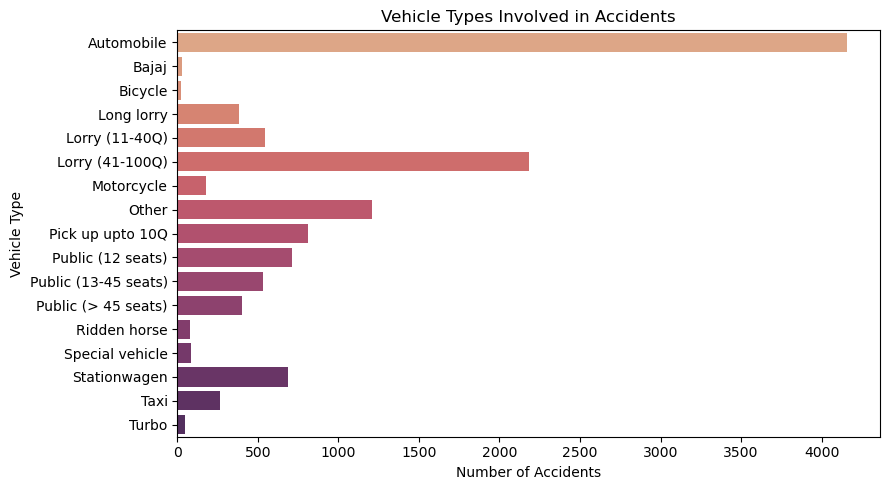

In [70]:
plt.figure(figsize=(9,5))
sns.barplot(x=vehicle_table["Accident_Count"], y=vehicle_table.index, hue=vehicle_table.index, palette="flare", legend= False)
plt.title("Vehicle Types Involved in Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Vehicle Type")
plt.tight_layout()
plt.show()

- The analysis shows that **Automobiles** were involved in the highest number of traffic accidents, recording **4,155 accidents**. This is almost twice the number recorded by the second most common vehicle type.

- **Lorries (41–100Q)** ranked second with **2,186 accidents**, followed by **Other vehicle types (1,238)** and **Pick-up trucks (up to 10Q) (811)**. Public transport vehicles, including **12-seat**, **13–45 seat**, and **over 45-seat** vehicles, were also involved in a considerable number of accidents.

- On the other hand, **Bicycles (21 accidents)**, **Bajajs (29 accidents)** and **Turbo vehicles (76 accidents)** recorded the fewest accidents in the dataset.

- Overall, the results suggest that vehicle types that are more commonly used on the roads, particularly automobiles and lorries, account for the largest share of reported traffic accidents.

Q9. Which road users are most affected?

Understanding the characteristics of road users affected by accidents helps identify the groups that are most vulnerable. This information can assist road safety agencies in designing targeted awareness campaigns and safety interventions.

To answer this question, the casualties were analysed by **sex**, **age group**, and **injury severity**. Frequency tables were produced to identify which demographic groups were most commonly affected.

In [72]:
# value_counts on who is affected (sex + age band of casualty)
sex_counts = df2["Sex_of_casualty"].value_counts()
age_counts = df2["Age_band_of_casualty"].value_counts().sort_index()

print("\nCasualties by sex:")
print(sex_counts)
print("\nCasualties by age band:")
print(age_counts)


# Grouping + aggregation: casualty severity breakdown by age band
age_severity = (df2.groupby("Age_band_of_casualty", observed=True)["Casualty_severity_label"]
                 .value_counts()
                 .unstack(fill_value=0))
age_severity





Casualties by sex:
Sex_of_casualty
Male      5253
na        4443
Female    2620
Name: count, dtype: int64

Casualties by age band:
Age_band_of_casualty
Under 18    1279
18-30       3145
31-50       2455
Over 51      994
Unknown     4443
Name: count, dtype: int64


Casualty_severity_label,Fatal Injury,Serious Injury,Slight Injury,Unknown
Age_band_of_casualty,,,,
Under 18,7,143,1129,0
18-30,5,275,2865,0
31-50,4,214,2237,0
Over 51,10,139,845,0
Unknown,0,0,0,4443


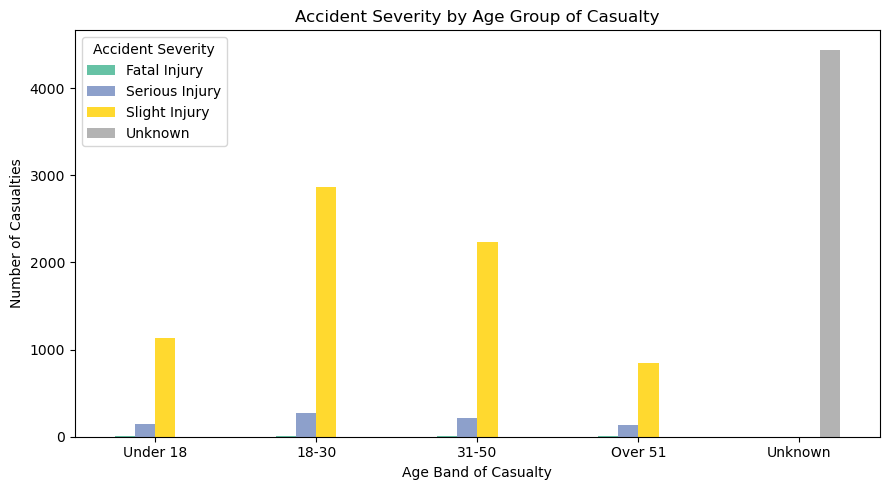

In [74]:
age_severity.plot(
    kind="bar",
    figsize=(9,5),
    colormap="Set2"
)

plt.title("Accident Severity by Age Group of Casualty")
plt.xlabel("Age Band of Casualty")
plt.ylabel("Number of Casualties")
plt.xticks(rotation=0)
plt.legend(title="Accident Severity")
plt.tight_layout()
plt.show()

- The casualty records show that **male road users** were the most affected by traffic accidents, accounting for **5,253 casualties**, compared to **2,620 female casualties**. In addition, **4,443 records** had an **unknown** sex, indicating that this information was not available for a substantial number of casualties.

- Looking at age groups, the **18–30 years** category recorded the highest number of casualties (**3,145**), followed by the **31–50 years** age group (**2,455**). Children under 18 accounted for **1,279** casualties, while people aged **over 51 years** recorded the lowest number of casualties (**994**). There were also **4,443 records** where the casualty's age group was unknown.

- When accident severity is considered alongside age group, **slight injuries** were the most common outcome across all age categories. The **18–30 years** group recorded the highest number of slight injuries (**2,865**), followed by the **31–50 years** group (**2,237**). Fatal injuries were relatively uncommon across all age groups, with the **over 51 years** category recording the highest number of fatal injuries (**10 cases**).

##### Additional Analysis: Association Between Key Categorical Variables


Most variables in this dataset are categorical, making a traditional Pearson correlation analysis unsuitable. Instead, Cramér's V was used to measure the strength of association between selected categorical variables.

The values range from **0 to 1**, where:
- **0** indicates no association.
- **1** indicates a very strong association.

This analysis provides an overview of how the key variables relate to one another and helps identify which factors are most closely associated.

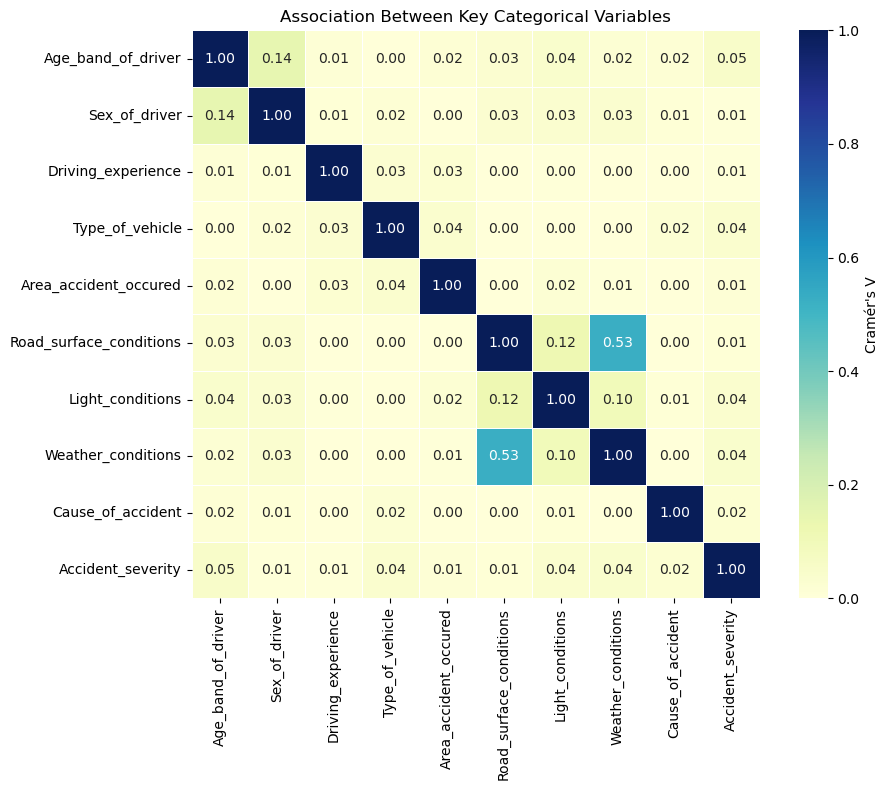

In [ ]:
# Create a function to calculate Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Select the variables to include
association_cols = [
    "Age_band_of_driver",
    "Sex_of_driver",
    "Driving_experience",
    "Type_of_vehicle",
    "Area_accident_occured",
    "Road_surface_conditions",
    "Light_conditions",
    "Weather_conditions",
    "Cause_of_accident",
    "Accident_severity"
]

# Compute the association matrix
association_matrix = pd.DataFrame(
    np.zeros((len(association_cols), len(association_cols))),
    index=association_cols,
    columns=association_cols
)

for col1 in association_cols:
    for col2 in association_cols:
        association_matrix.loc[col1, col2] = cramers_v(df2[col1], df2[col2])


# Plot the heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    association_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Cramér's V"})
plt.title("Association Between Key Categorical Variables")
plt.tight_layout()
plt.show()


- The heatmap displays the strength of association between the selected categorical variables using **Cramér's V**, where values closer to **0** indicate a weak association and values closer to **1** indicate a strong association.

- As expected, each variable has a value of **1.00** with itself, as shown along the diagonal of the heatmap.

- Among the different variable pairs, the strongest association was observed between **Road Surface Conditions** and **Weather Conditions** (**Cramér's V = 0.53**). This moderate association is expected because weather conditions such as rain or snow can directly influence whether road surfaces are dry, wet, or slippery.

- A weak positive association was also observed between **Road Surface Conditions** and **Light Conditions** (**0.12**), as well as between **Weather Conditions** and **Light Conditions** (**0.10**). These values suggest that lighting and weather conditions have some relationship, although it is not particularly strong.

- The association between **Age Band of Driver** and **Sex of Driver** (**0.14**) was also weak, indicating only a slight relationship between these variables in the recorded accident cases.

- Most of the remaining variable pairs have association values below **0.10**, indicating very weak or negligible relationships. In particular, **Accident Severity** shows very weak associations with the other selected variables, suggesting that no single categorical factor in this analysis strongly explains the severity of accidents. This implies that accident severity is likely influenced by a combination of several factors rather than one variable alone.

## 11. Recommendations

Based on the findings from the exploratory data analysis, the following recommendations are proposed:

1. Strengthen road safety awareness campaigns focusing on safe following distances, proper lane changing, and defensive driving, as these were among the leading causes of accidents.

2. Increase traffic enforcement during peak accident periods, particularly during the **morning** and **late afternoon**, when accident frequencies were highest.

3. Allocate additional traffic officers and road safety resources to high-risk areas such as **office areas**, **residential areas**, and other locations with consistently high accident frequencies.

4. Implement targeted road safety education programmes for **young drivers and young adults (18–30 years)**, as this age group accounted for the largest proportion of casualties.

5. Improve road infrastructure where necessary by ensuring clear road markings, adequate traffic signs, and effective traffic management in accident-prone locations.

6. Encourage routine driver training and refresher programmes to promote safer driving practices and reduce accidents caused by human error.

7. Improve accident data collection by recording complete information for all accident reports, including casualty details, vehicle information, and temporal variables such as **date and month**. More complete data would support deeper analyses and more accurate decision-making in future studies.

8. Future work could extend this analysis by developing predictive machine learning models to identify factors associated with accident severity and to support evidence-based road safety interventions.